# CPU USAGE 50 VUS 5 MENIT LARAVEL


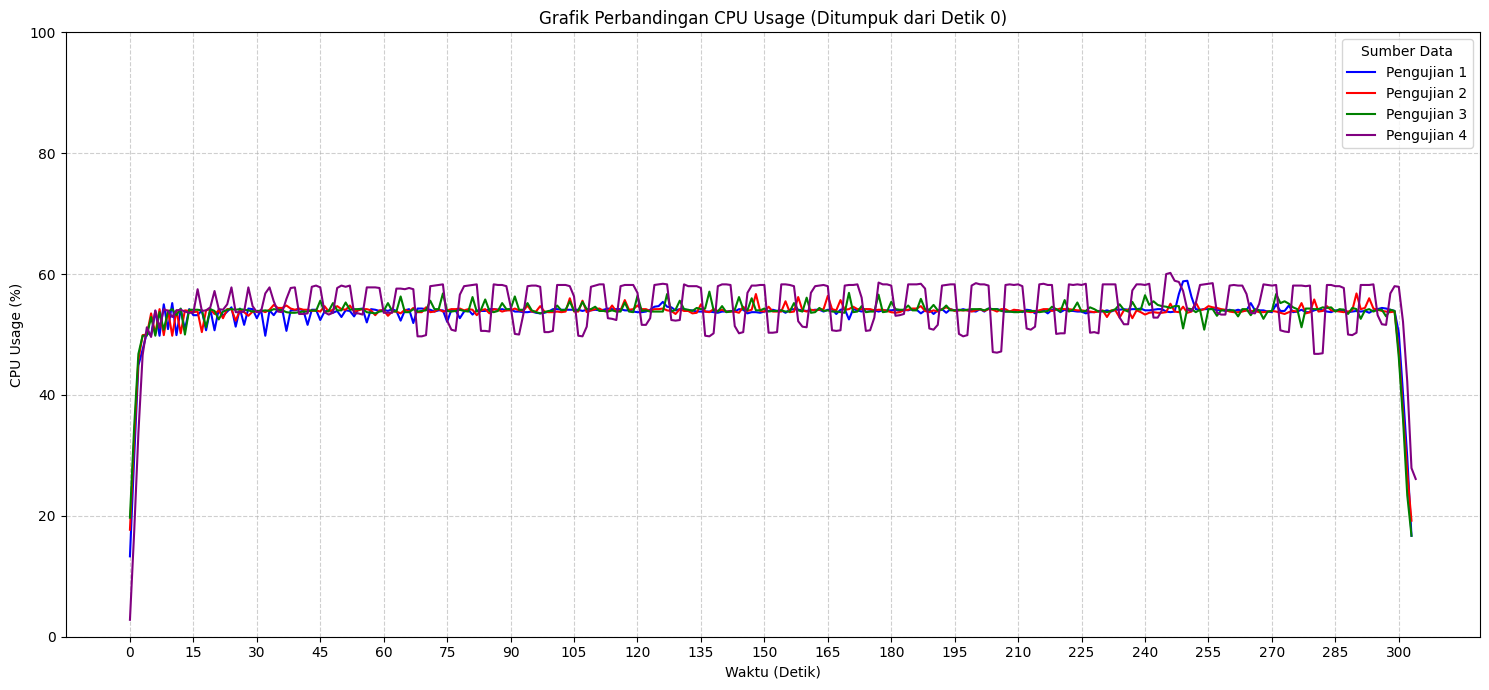

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# List file CSV
file_paths = [
    "/Testing/CPU/50 VUS 5 Menit/CPU-data-2026-07-06 11_16_55.csv",
    "/Testing/CPU/50 VUS 5 Menit/CPU-data-2026-07-06 11_25_05.csv",
    "/Testing/CPU/50 VUS 5 Menit/CPU-data-2026-07-06 11_33_22.csv",
    "/Testing/CPU/50 VUS 5 Menit/CPU-data-2026-07-06 11_41_56.csv"
]

colors = ['blue', 'red', 'green', 'purple']
labels = ['Pengujian 1', 'Pengujian 2', 'Pengujian 3', 'Pengujian 4']

plt.figure(figsize=(15, 7))

for i, file_path in enumerate(file_paths):
    try:
        df = pd.read_csv(file_path)

        if 'Time' not in df.columns:
            continue

        idle_col = 'Idle - Waiting for something to happen'
        if idle_col in df.columns:
            idle_val = pd.to_numeric(df[idle_col].str.replace('%', ''), errors='coerce')
            cpu_usage = 100 - idle_val
        else:
            continue

        # Normalisasi Waktu: Ubah waktu menjadi 'detik ke-n' dari awal data
        # Ini memastikan semua garis mulai dari titik 0 yang sama (bertumpuk)
        df['Time'] = pd.to_datetime(df['Time'])
        relative_seconds = (df['Time'] - df['Time'].min()).dt.total_seconds()

        # Plot menggunakan detik sebagai sumbu X agar benar-benar menumpuk
        plt.plot(relative_seconds, cpu_usage, color=colors[i], label=labels[i], linewidth=1.5)

    except Exception as e:
        print(f"Gagal memproses file {file_path}: {e}")

# Pengaturan Sumbu Y (0-100%)
plt.ylim(0, 100)
plt.ylabel('CPU Usage (%)')

# Pengaturan Sumbu X (Interval 15 Detik)
# Kita buat ticks setiap 15 detik
max_time = 300 # asumsi 5 menit, atau bisa disesuaikan
plt.xticks(range(0, int(max_time) + 15, 15))

plt.title('Grafik Perbandingan CPU Usage (Ditumpuk dari Detik 0)')
plt.xlabel('Waktu (Detik)')
plt.legend(title="Sumber Data", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# RAM USAGE 50 VUS 5 MENIT LARAVEL


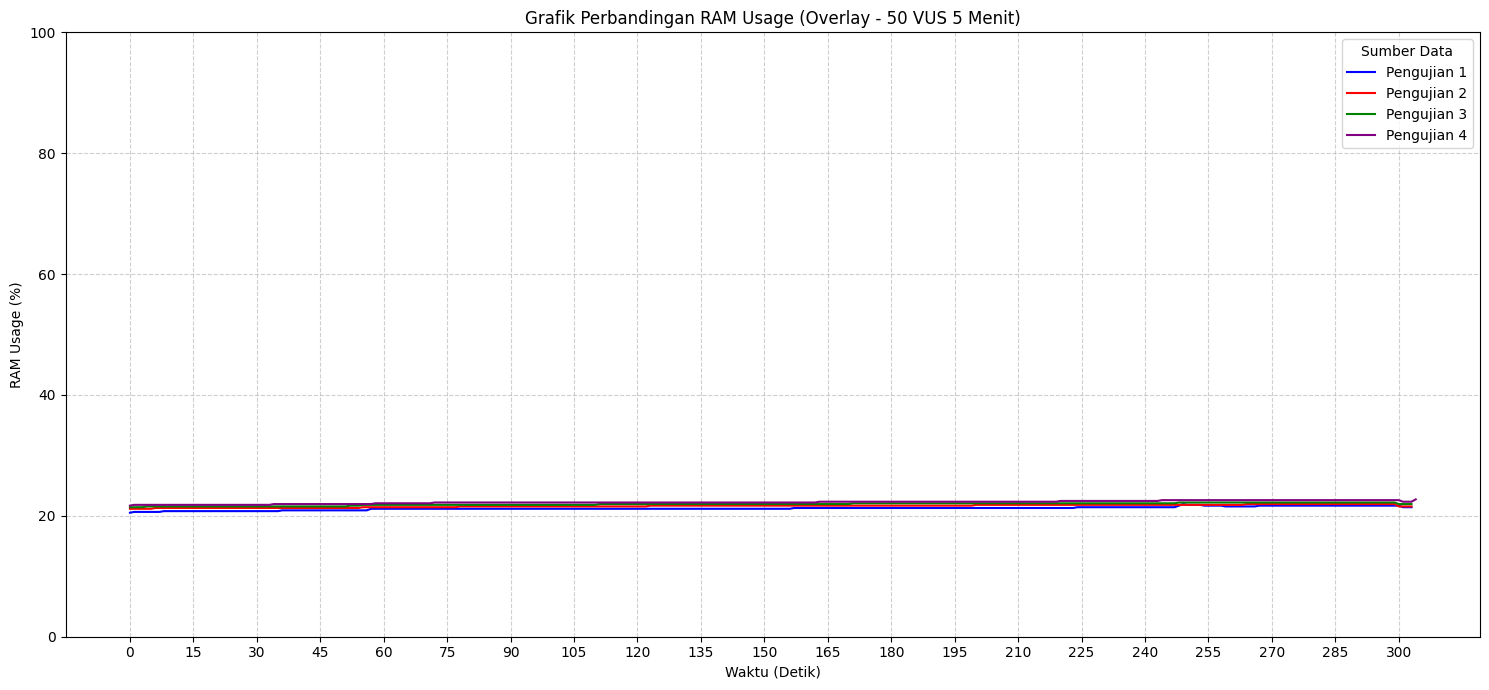

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# List file RAM sesuai yang ada di /content/
file_paths = [
    "/Testing/RAM/50 VUS 5 Menit/Memory-data-2026-07-06 11_17_09.csv",
    "/Testing/RAM/50 VUS 5 Menit/Memory-data-2026-07-06 11_25_26.csv",
    "/Testing/RAM/50 VUS 5 Menit/Memory-data-2026-07-06 11_33_39.csv",
    "/Testing/RAM/50 VUS 5 Menit/Memory-data-2026-07-06 11_42_06.csv"
]

total_ram_gib = 7.7
colors = ['blue', 'red', 'green', 'purple']
labels = ['Pengujian 1', 'Pengujian 2', 'Pengujian 3', 'Pengujian 4']

plt.figure(figsize=(15, 7))

for i, file_path in enumerate(file_paths):
    try:
        df = pd.read_csv(file_path)

        # Nama kolom yang ditemukan di dataset
        unused_col = 'Unused - Free memory unassigned'

        if 'Time' in df.columns and unused_col in df.columns:
            # Bersihkan ' GiB' dan konversi ke angka
            unused_val = pd.to_numeric(df[unused_col].str.replace(' GiB', '', regex=False), errors='coerce')

            # Rumus: Penggunaan = 7.7 - Unused
            used_gib = total_ram_gib - unused_val
            ram_usage_percent = (used_gib / total_ram_gib) * 100

            # Normalisasi waktu agar semua mulai dari detik 0 (Ditumpuk)
            df['Time'] = pd.to_datetime(df['Time'])
            relative_seconds = (df['Time'] - df['Time'].min()).dt.total_seconds()

            plt.plot(relative_seconds, ram_usage_percent, color=colors[i], label=labels[i], linewidth=1.5)
        else:
            print(f"Kolom tidak ditemukan di {file_path}")

    except Exception as e:
        print(f"Gagal memproses file {file_path}: {e}")

# Pengaturan Grafik
plt.ylim(0, 100)
plt.ylabel('RAM Usage (%)')

# Sumbu X interval 15 detik
plt.xticks(range(0, 315, 15))

plt.title('Grafik Perbandingan RAM Usage (Overlay - 50 VUS 5 Menit)')
plt.xlabel('Waktu (Detik)')
plt.legend(title="Sumber Data", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()